In [999]:
print(f"In this notebook we try to find whether catenary mooring with partial polyester lines is viable for the system. \n"
      "Only the larger depths are considered (80 to 100 m) as taut mooring will be used for shallower regions")

In this notebook we try to find whether catenary mooring with partial polyester lines is viable for the system. 
Only the larger depths are considered (80 to 100 m) as taut mooring will be used for shallower regions


In [1000]:
import numpy as np
import pandas as pd
import math as math
from scipy import optimize
from scipy.interpolate import interp1d

from MoorLib import moorSeg
from MoorLib import moorLine2D
from MoorLib import moorLine3D

import matplotlib.pylab as plt
from matplotlib.legend_handler import HandlerLine2D

%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

In [1001]:
g = 9.81 #m/s2
tunn_width = 28 #m 

Wpm_c_heavy = 920 #kg/m, diameter 220 mm 
Wpm_c_light = 376 #kg/m, diameter 140 mm 
Wpm_poly = 10.9 #kg/m, polyester, diameter

Ea_c = 1725000000
Ea_poly = 242000000

Text(0, 0.5, 'Elevation m')

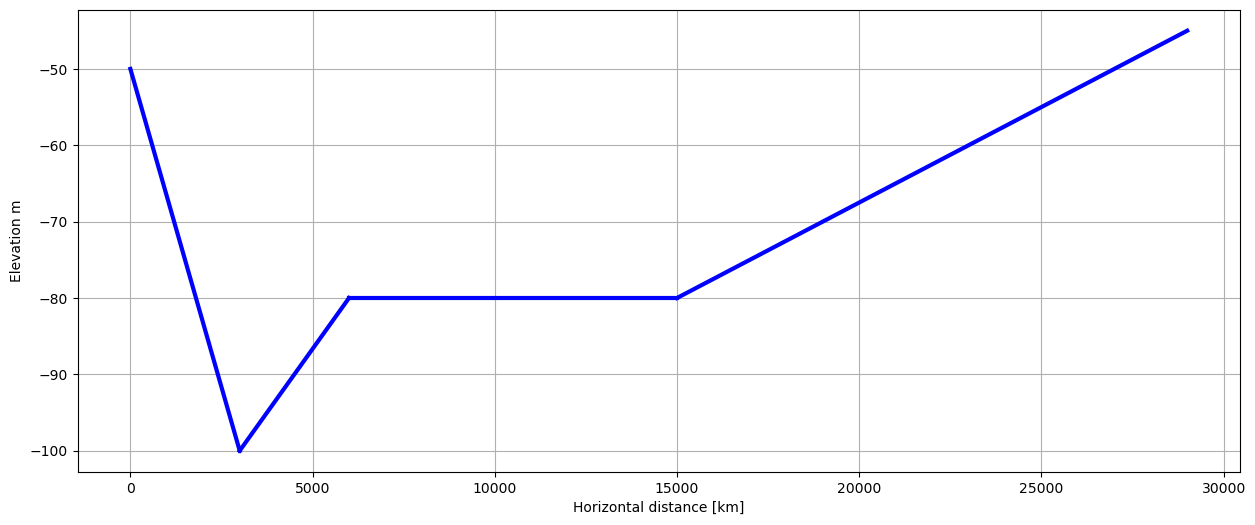

In [1002]:
x1 = np.linspace(0, 3000)
x2 = np.linspace(3000, 6000)
x3 = np.linspace(6000, 15000)
x4 = np.linspace(15000, 29000)

y1 = -50 -1/60 * x1
y2 = -100 - 1/150 * (3000-x2)
y3 = -80 + 0*x3
y4 = -80 - 1/400 * (15000 - x4) 

plt.figure()
plt.plot(x1, y1, 'b-', lw=3)
plt.plot(x2, y2, 'b-', lw=3)
plt.plot(x3, y3, 'b-', lw=3)
plt.plot(x4, y4, 'b-', lw=3)
plt.grid()
plt.xlabel('Horizontal distance [km]')
plt.ylabel('Elevation m')

In [1003]:
def catenary_end_xz(W_pm, L_tot, EA, V_AN, H_AN, L_susp):
    
    W = W_pm*L_susp*g
        
    s = L_susp    
    z_t1 = 1 + (V_AN/H_AN)**2
    z_t2 = 1 + ((V_AN - W*s/L_susp)/H_AN)**2
    z = W*s/EA * (s/2/L_susp - V_AN/W) - H_AN*L_susp/W*(np.sqrt(z_t1) - np.sqrt(z_t2))            
    x_susp = H_AN*s/EA + H_AN*L_susp/W*(np.arcsinh(V_AN/H_AN) - np.arcsinh((V_AN - W*s/L_susp)/H_AN))
    x_bed = L_tot - L_susp
    x = x_bed + x_susp
        
    return x, z

In [1004]:
def catenary_xz(W_pm, L_tot, EA, V_AN, H_AN, L_susp, ds):
        
    W = W_pm * L_susp * g
    
    # c_s = [0]
    # c_x = [L_tot - L_susp]
    # c_z = [0]
    # c_H = [H_AN]
    # c_V = [V_AN]
    
    c_s = [0, 0]    
    c_x = [0, L_tot - L_susp]
    c_z = [0, 0]
    c_H = [H_AN, H_AN]
    c_V = [V_AN, V_AN]
    
    Ns = math.floor(L_susp/ds)
    ds = L_susp/Ns
    for i in range(1,Ns+1):
        s = c_s[-1]+ds        
        z_t1 = 1 + (V_AN/H_AN)**2
        z_t2 = 1 + ((V_AN - W*s/L_susp)/H_AN)**2
        z = W*s/EA * (s/2/L_susp-V_AN/W) - H_AN*L_susp/W*(np.sqrt(z_t1) - np.sqrt(z_t2))        
        x_susp = H_AN*s/EA + H_AN*L_susp/W*(np.arcsinh(V_AN/H_AN) - np.arcsinh((V_AN - W*s/L_susp)/H_AN))        
        V = V_AN + W_pm*s*g
        x = L_tot - L_susp + x_susp
        
        c_s.append(s)        
        c_x.append( x )
        c_z.append( z )        
        c_V.append( V )
        
    # print(c_s[-1], c_x[-1], c_z[-1], c_V[-1])
        
    return c_s, c_x, c_z, c_V

In [1005]:
def objective_fnc(sol, *data):        
    H_AN = sol[0]
    L = sol[1] #suspended length
    W_pm, L_tot, EA, V_AN, xtarg, ztarg  = data
    x, z = catenary_end_xz(W_pm, L_tot, EA, V_AN, H_AN, L)    
    return np.array( [abs(ztarg-z),  abs(xtarg-x)] )

In [1006]:
def calcSysRestoringForce( trans_xyz, msg=False ):

    for iLine in lineMat:
        xfl = iLine.xflRef + trans_xyz[0]
        yfl = iLine.yflRef + trans_xyz[1]
        zfl = iLine.zflRef + trans_xyz[2]
        iLine.solveFl_xyz( xfl, yfl, zfl, 
                          HStart = iLine.retRef_H(), LBedStart = iLine.retRef_LBed() )
    
    Fx = sum([ iLine.retFlForce()[0] for iLine in lineMat])
    Fy = sum([ iLine.retFlForce()[1] for iLine in lineMat])
    Fz = sum([ iLine.retFlForce()[2] for iLine in lineMat])    
    
    
    if(msg):
        #print( min([iLine.retLBed() for iLine in lineMat]) )
        for iLine in lineMat:            
            print( iLine.xfl, iLine.yfl, iLine.zfl, 
                  iLine.l2d.xe, iLine.l2d.ze, iLine.l2d.H0, iLine.retLBed() )
            
        
    return Fx, Fy, Fz

In [1007]:
depth_pts = np.array([52.5, 55, 57.5, 60, 62.5, 65, 67.5, 70, 72.5])
Fz_pts = np.array([10829.99, 12028.20, 13201.46, 14342.84, 15449.05, 16519.24, 17554.05, 18554.98, 19523.93])
q_buoy = 358.86  # kN/m
Fz_func = interp1d(depth_pts, Fz_pts, kind='quadratic')

def depth_profile(x):
    # 1800 -> 3000 : 52.5 -> 72.5
    if x <= 3000:
        return (52.5 + (72.5 - 52.5) * (x - 1800) / (3000 - 1800))
    # 3000 -> 6000 : 72.5 -> 52.5
    elif x <= 6000:
        return (72.5- (72.5 - 52.5) * (x - 3000) / (6000 - 3000))
    # 6000 -> 15000 : flat at 52.5
    else:
        return 52.5

moor_rows = []
x = 1800.0
while x <= 15000:
    d = depth_profile(x)

    Fz = float(Fz_func(d))

    spacing = Fz / q_buoy

    moor_rows.append({'x': x, 'depth': d, 'Fz': Fz, 'spacing': spacing})

    x += spacing

x_positions = np.array([r['x'] for r in moor_rows])
depths = np.array([r['depth'] for r in moor_rows])

# for i, r in enumerate(moor_rows):
    # print(
    #     f"Row {i+1:02d} | "
    #     f"x = {r['x']:8.2f} m | "
    #     f"d = {r['depth']:6.2f} m | "
    #     f"Fz = {r['Fz']/1000:6.2f} kN | "
    #     f"spacing = {r['spacing']:5.2f} m"
    # )

In [1008]:
# depths = np.array([52.5, 55, 57.5, 60, 62.5, 65, 67.5, 70, 72.5]) # vertical distance between bottom and midpoint tunnel at z = -27.5
moor_spacing = 25 # distance between mooring attachments

lineMat=[]
rowInfo = []  # Track which row each line belongs to

# for row_idx in range(len(depths)):
#     d = depths[row_idx]
#     y = 1800 + row_idx * 30

for row_idx, row_now in enumerate(moor_rows):      
    d = row_now['depth']
    y = row_now['x']
    
    flDist = tunn_width / 2
    # print(d)

    # anch_dist = 8 * d + flDist
    # Ltot = np.sqrt(anch_dist**2 + d**2) * 1.3 * 1.02**( (72.5 - d) / 20)
    # Ltot = (anch_dist + d) * 0.83 * 1.05**( (72.5 - d) / 20) 

    Ltot = 8 * d
    anch_dist = Ltot * 1.02

    # print(f"{np.sqrt(anch_dist**2 + d**2)} ") # Check whether Ltot is in reasonable range, should be the middle value
    # print(Ltot)
    # print(f"{anch_dist + d} \n")

    segMat = []
    segMat.append( moorSeg((Ltot - d), Wpm_c_heavy, Ea_c) )
    segMat.append( moorSeg((d - 5), Wpm_poly, Ea_poly) )
    segMat.append( moorSeg(5, Wpm_c_light, Ea_c) )

    # print(Ltot)
    # print((Ltot - d))
    # print(d - 5)
    # print(f"{(Ltot - d) + (d - 5) + 5} \n")

    nLine = 6
    lineAng = [0, 2.5, 177.5, 180, 182.5, 357.5] 

    
    for iAng in lineAng:
        xan = anch_dist * np.cos(iAng * np.pi / 180.0)
        yan = y + anch_dist * np.sin(iAng * np.pi / 180.0)
        zan = (- d)
        lineMat.append(moorLine3D(xan, yan, zan, seg=segMat))
        rowInfo.append({'row': row_idx, 'angle': iAng, 'depth': d, 'lineLength': Ltot})

    current_lines = lineMat[-nLine:]        # last 6 lines
    for iAng, iLine in zip(lineAng, current_lines):
        xfl = flDist * np.cos(iAng * np.pi / 180.0)
        yfl = y #+ flDist * np.sin(iAng * np.pi / 180.0)
        zfl = 0
        # iLine.solveFl_xyz(xfl, yfl, zfl)
        try:
            iLine.solveFl_xyz(xfl, yfl, zfl)
            # print(f"  Solved: ang={iAng}, xan={iLine.xan:.1f}, zan={iLine.zan:.1f} -> xfl={xfl:.1f}, zfl={zfl}")
        except Exception as e:
            print(f"  FAILED: ang={iAng}, xan={iLine.xan:.1f}, zan={iLine.zan:.1f}, error: {e}")
        

    Fx = float(sum([iLine.retFlForce()[0] for iLine in current_lines]))
    Fy = float(sum([iLine.retFlForce()[1] for iLine in current_lines]))
    Fz = float(sum([iLine.retFlForce()[2] for iLine in current_lines]))
    # print(f"Fx, Fy, Fz = {Fx:.2f} {Fy:.2f} {Fz/1000:.2f} kN \n")

    for j in range(0, nLine):
        iLine = current_lines[j]
        # print(j, 'LTot', iLine.retLTot(), 'LSusp', iLine.retLSusp(),
        #     'LBed', iLine.retLBed(), 'H0', iLine.l2d.H0, 'VEnd', iLine.l2d.Ve, 
        #     np.linalg.norm([iLine.l2d.H0, iLine.l2d.Ve], ord=2)/1000)
    print(j, 'LTot', iLine.retLTot(), 'LSusp', iLine.retLSusp(),
            'LBed', iLine.retLBed(), 'H0', iLine.l2d.H0, 'VEnd', iLine.l2d.Ve, 
            np.linalg.norm([iLine.l2d.H0, iLine.l2d.Ve], ord=2)/1000)
        
    # print(f"\n")

    for iLine in current_lines:             # only set ref for current lines
        iLine.setRef_FLxyz(iLine.xfl, iLine.yfl, iLine.zfl)
        iLine.setRef_H(iLine.retFlForce_H())
        iLine.setRef_LBed(iLine.retLBed())
    

    # print(lineMat)
    # print(rowInfo)

    

5 LTot 420.0 LSusp 248.8863533710701 LBed 171.1136466289299 H0 4927781.541704985 VEnd -1795948.0439445819 5244.850836708012
5 LTot 424.02384959780045 LSusp 253.8609815458243 LBed 170.16286805197615 H0 5088166.997956395 VEnd -1836359.3355003204 5409.404681494238
5 LTot 428.1379804981832 LSusp 258.93520166612427 LBed 169.20277883205893 H0 5252883.262531798 VEnd -1877568.8201426654 5578.355245424823
5 LTot 432.34404739541026 LSusp 264.1080790353241 LBed 168.23596836008613 H0 5421897.146607747 VEnd -1919566.2174209687 5751.669595122539
5 LTot 436.64371704197094 LSusp 269.3785680546528 LBed 167.26514898731813 H0 5595165.396128717 VEnd -1962340.2325284008 5929.304765167317
5 LTot 441.03866734327096 LSusp 274.7455234753317 LBed 166.29314386793928 H0 5772634.944762839 VEnd -2005878.6588637964 6111.2080147530805
5 LTot 445.5305863925115 LSusp 280.20771230033665 LBed 165.32287409217489 H0 5954243.2531824475 VEnd -2050168.4865233318 6297.317170129043
5 LTot 450.12117144399224 LSusp 285.7638261062

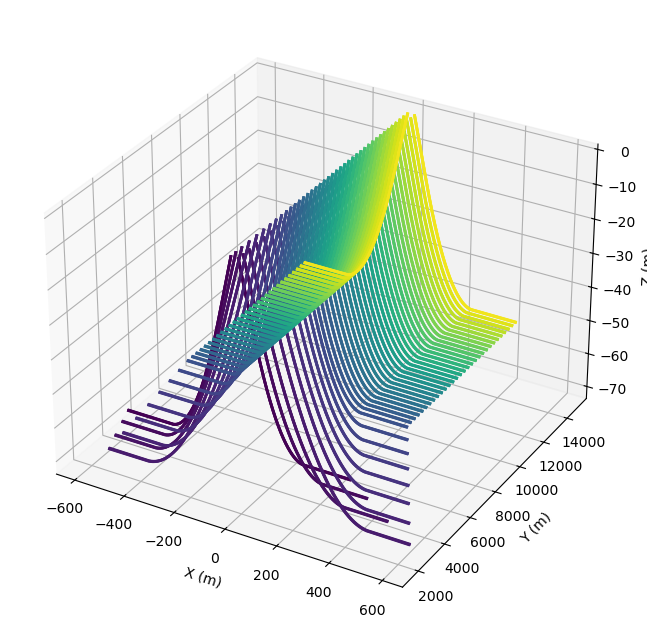

In [1009]:
# Plot all mooring lines with color coding by row
line_plots = [(iLine, info, iLine.plotLine3D(0.1)) for iLine, info in zip(lineMat, rowInfo)]

rows_to_plot = set(range(0, len(moor_rows), 10))  # every 10th row

plt.figure(figsize=(15, 8))
ax = plt.axes(projection='3d')

# Color map for rows
colors = plt.cm.viridis(np.linspace(0, 1, len(moor_rows)))

# Plot lines grouped by row
count = 0

for line_idx, (iLine, info, (x, y, z, segTyp)) in enumerate(line_plots):
# for line_idx, (iLine, info) in enumerate(zip(lineMat, rowInfo)):
    if info['row'] not in rows_to_plot:
        continue
    # x, y, z, segTyp = iLine.plotLine3D(0.1)
    color = colors[info['row']]
    if (line_idx - count*6) == 0:
        ax.plot(x, y, z, color=color, linewidth=2, 
            label=f"Row {info['row']} (Depth={info['depth']}m, L={info['lineLength']}m)")
        count += 1
    else:
        ax.plot(x, y, z, color=color, linewidth=2)
    

# Plot fairleads
fairlead_x = [iLine.xfl for iLine in lineMat]
fairlead_y = [iLine.yfl for iLine in lineMat]
fairlead_z = [iLine.zfl for iLine in lineMat]
# ax.scatter(fairlead_x, fairlead_y, fairlead_z, c='red', s=100, marker='o', label='Fairleads')

# Plot anchors
anchor_x = [iLine.xan for iLine in lineMat]
anchor_y = [iLine.yan for iLine in lineMat]
anchor_z = [iLine.zan for iLine in lineMat]
# ax.scatter(anchor_x, anchor_y, anchor_z, c='blue', s=100, marker='^', label='Anchors')

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
# ax.set_ylim(0, 27000)
ax.set_zlabel('Z (m)')
# ax.set_title('3D Mooring System - Multiple Depths')
ax.grid(True)
# ax.legend(loc='upper right', fontsize=8)
plt.show()


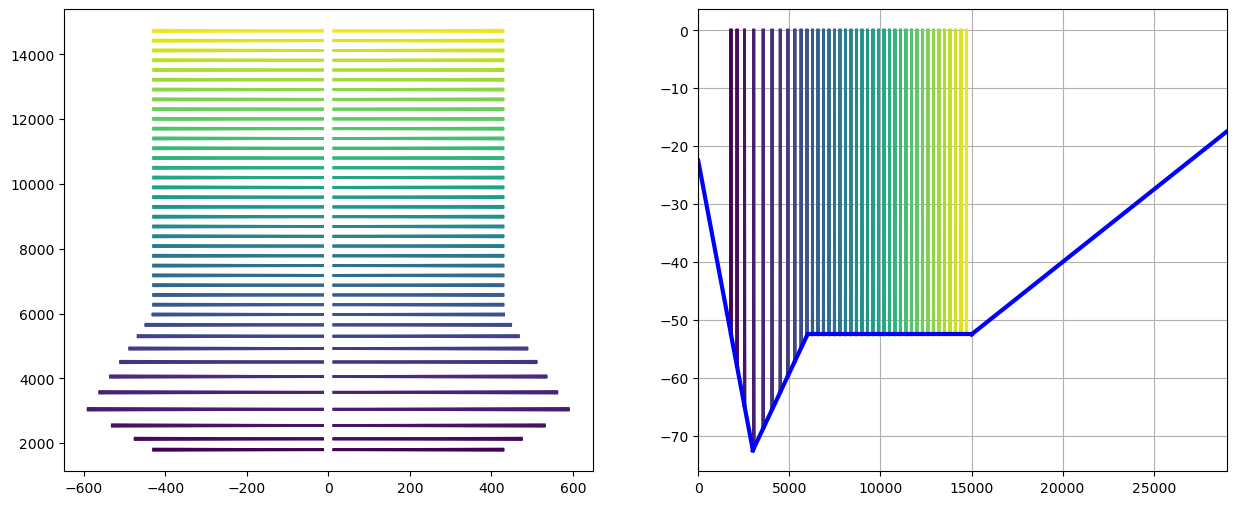

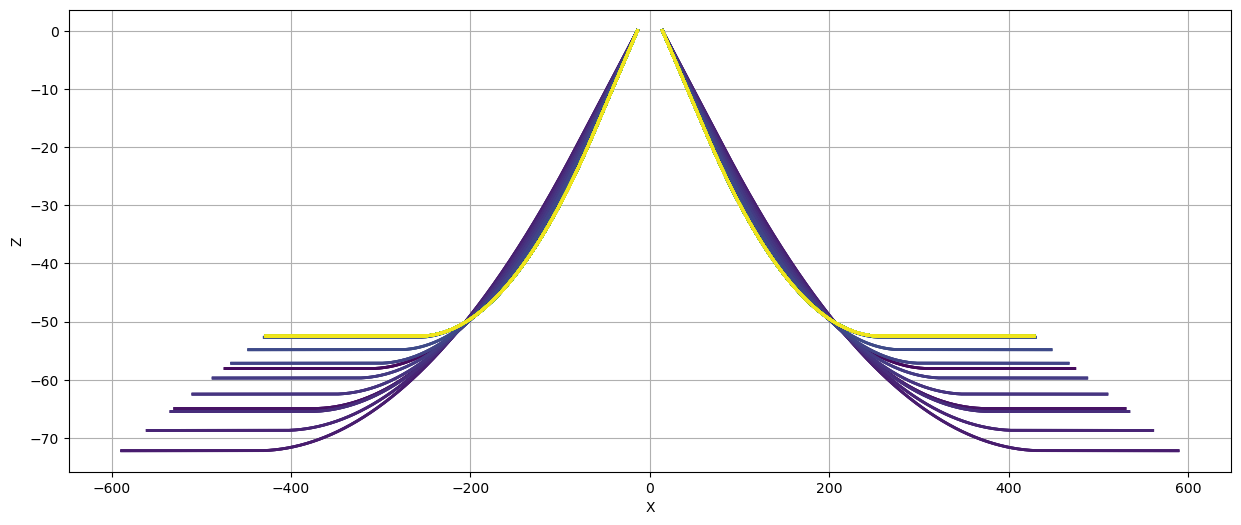

In [1010]:
f, (ax1, ax2) = plt.subplots(1,2)
for line_idx, (iLine, info, (x, y, z, segTyp)) in enumerate(line_plots):
# for line_idx, (iLine, info) in enumerate(zip(lineMat, rowInfo)):
    if info['row'] not in rows_to_plot:
        continue
    # x, y, z, segTyp = iLine.plotLine3D(0.1)
    color = colors[info['row']]
    ax1.plot(x, y, color=color, linewidth=2, 
            label=f"Row {info['row']} (Depth={info['depth']}m, L={info['lineLength']}m)")
# ax1.set_ylim(0, 27000)

for line_idx, (iLine, info, (x, y, z, segTyp)) in enumerate(line_plots):    
# for line_idx, (iLine, info) in enumerate(zip(lineMat, rowInfo)):
    if info['row'] not in rows_to_plot:
        continue
    # x, y, z, segTyp = iLine.plotLine3D(0.1)
    color = colors[info['row']]
    ax2.plot(y,z, color=color, linewidth=2, 
            label=f"Row {info['row']} (Depth={info['depth']}m, L={info['lineLength']}m)")


x1 = np.linspace(0, 3000)
x2 = np.linspace(3000, 6000)
x3 = np.linspace(6000, 15000)
x4 = np.linspace(15000, 29000)

y1 = -22.5 -1/60 * x1
y2 = -92.5 + 1/150 * x2
y3 = -52.5 + 0*x3
y4 = 1/400*x4 - 90 


ax2.plot(x1, y1, 'b-', lw=3)
ax2.plot(x2, y2, 'b-', lw=3)
ax2.plot(x3, y3, 'b-', lw=3)
ax2.plot(x4, y4, 'b-', lw=3)
ax2.set_xlim(0, 29000)
ax2.grid()

count = 0

plt.figure()
for line_idx, (iLine, info, (x, y, z, segTyp)) in enumerate(line_plots):
# for line_idx, (iLine, info) in enumerate(zip(lineMat, rowInfo)):
    if info['row'] not in rows_to_plot:
        continue
    # x, y, z, segTyp = iLine.plotLine3D(0.1)
    color = colors[info['row']]
    if (line_idx - count*6) == 0:
        plt.plot(x, z, color=color, linewidth=2, 
            label=f"Row {info['row']} (Depth={info['depth']}m, L={info['lineLength']}m)")
        count += 1
    else:
        plt.plot(x, z, color=color, linewidth=2)
plt.xlabel('X')
plt.ylabel('Z')
# plt.legend()
plt.grid()
plt.show()

count = 0

# plt.figure()
# for line_idx, (iLine, info, (x, y, z, segTyp)) in enumerate(line_plots):
# # for line_idx, (iLine, info) in enumerate(zip(lineMat, rowInfo)):
# #     x, y, z, segTyp = iLine.plotLine3D(0.1)
#     color = colors[info['row']]
#     plt.plot(y,z, color=color, linewidth=2, 
#             label=f"Row {info['row']} (Depth={info['depth']}m, L={info['lineLength']}m)")
    
# x1 = np.linspace(0, 3000)
# x2 = np.linspace(3000, 6000)
# x3 = np.linspace(6000, 15000)
# x4 = np.linspace(15000, 29000)

# y1 = -22.5 -1/60 * x1
# y2 = -92.5 + 1/150 * x2
# y3 = -52.5 + 0*x3
# y4 = 1/400*x4 - 90 
# xticks = np.linspace(0, 27000, 10)
# yticks = np.linspace(0, -100, 11)

# plt.plot(x1, y1, 'b-', lw=3)
# plt.plot(x2, y2, 'b-', lw=3)
# plt.plot(x3, y3, 'b-', lw=3)
# plt.plot(x4, y4, 'b-', lw=3)
# plt.xlabel('Horizontal distance [m]')
# # plt.ylabel('Elevation [m]')
# plt.xticks(xticks)
# # plt.yticks(yticks)
# plt.grid()
# plt.show()

In [ ]:
delta = 0.2  # perturbation step (m)

dx = np.arange(-6, 6 + delta, delta)
dz = np.arange(-6, 6 + delta, delta)

FRes_x = [calcSysRestoringForce([x, 0.0, 0.0]) for x in dx]
FRes_z = [calcSysRestoringForce([0.0, 0.0, z]) for z in dz]

fx_x = np.array([fx for fx, fy, fz in FRes_x])
fz_x = np.array([fz for fx, fy, fz in FRes_x])
fx_z = np.array([fx for fx, fy, fz in FRes_z])
fz_z = np.array([fz for fx, fy, fz in FRes_z])

dx_mid = (dx[:-1] + dx[1:]) / 2
dz_mid = (dz[:-1] + dz[1:]) / 2

Kxx_arr = np.diff(fx_x) / np.diff(dx)
Kzx_arr = np.diff(fz_x) / np.diff(dx)
Kxz_arr = np.diff(fx_z) / np.diff(dz)
Kzz_arr = np.diff(fz_z) / np.diff(dz)

Kxx = np.interp(0.0, dx_mid, Kxx_arr)
Kzx = np.interp(0.0, dx_mid, Kzx_arr)
Kxz = np.interp(0.0, dz_mid, Kxz_arr)
Kzz = np.interp(0.0, dz_mid, Kzz_arr)

print("Stiffness matrix [kN/m]:")
print(f"  [[Kxx, Kxz]   [[{Kxx/1000:.2f}, {Kxz/1000:.2f}]")
print(f"   [Kzx, Kzz]] =  [{Kzx/1000:.2f}, {Kzz/1000:.2f}]]")

fig, axes = plt.subplots(4, 2, figsize=(12, 16))

# --- Left column: force-excursion ---
axes[0, 0].plot(dx, fx_x / 1000, 'r-', lw=2)
axes[0, 0].set_xlabel('dx (m)')
axes[0, 0].set_ylabel('Fx (kN)')
axes[0, 0].set_title('Fx(x)')
axes[0, 0].grid(True)

axes[1, 0].plot(dz, fx_z / 1000, 'r-', lw=2)
axes[1, 0].set_xlabel('dz (m)')
axes[1, 0].set_ylabel('Fx (kN)')
axes[1, 0].set_title('Fx(z)')
axes[1, 0].grid(True)

axes[2, 0].plot(dx, fz_x / 1000, 'b-', lw=2)
axes[2, 0].set_xlabel('dx (m)')
axes[2, 0].set_ylabel('Fz (kN)')
axes[2, 0].set_title('Fz(x)')
axes[2, 0].grid(True)

axes[3, 0].plot(dz, fz_z / 1000, 'b-', lw=2)
axes[3, 0].set_xlabel('dz (m)')
axes[3, 0].set_ylabel('Fz (kN)')
axes[3, 0].set_title('Fz(z)')
axes[3, 0].grid(True)

# --- Right column: stiffness ---
axes[0, 1].plot(dx_mid, Kxx_arr / 1000, 'g-', lw=2)
axes[0, 1].axvline(0, color='k', linestyle='--', lw=1)
axes[0, 1].set_xlabel('dx (m)')
axes[0, 1].set_ylabel('Kxx (kN/m)')
axes[0, 1].set_title(f'Kxx  (at x=0: {Kxx/1000:.2f} kN/m)')
axes[0, 1].grid(True)

axes[1, 1].plot(dz_mid, Kxz_arr / 1000, 'g-', lw=2)
axes[1, 1].axvline(0, color='k', linestyle='--', lw=1)
axes[1, 1].set_xlabel('dz (m)')
axes[1, 1].set_ylabel('Kxz (kN/m)')
axes[1, 1].set_title(f'Kxz  (at z=0: {Kxz/1000:.2f} kN/m)')
axes[1, 1].grid(True)

axes[2, 1].plot(dx_mid, Kzx_arr / 1000, 'g-', lw=2)
axes[2, 1].axvline(0, color='k', linestyle='--', lw=1)
axes[2, 1].set_xlabel('dx (m)')
axes[2, 1].set_ylabel('Kzx (kN/m)')
axes[2, 1].set_title(f'Kzx  (at x=0: {Kzx/1000:.2f} kN/m)')
axes[2, 1].grid(True)

axes[3, 1].plot(dz_mid, Kzz_arr / 1000, 'g-', lw=2)
axes[3, 1].axvline(0, color='k', linestyle='--', lw=1)
axes[3, 1].set_xlabel('dz (m)')
axes[3, 1].set_ylabel('Kzz (kN/m)')
axes[3, 1].set_title(f'Kzz  (at z=0: {Kzz/1000:.2f} kN/m)')
axes[3, 1].grid(True)

fig.tight_layout()
plt.show()

c:\Users\bramv\OneDrive\Documenten\Civil Engineering Master\Floating and Submerged Structures\Notebooks\W3_Mooring\MoorLib.py:184: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root = optimize.fsolve(moorLine2D.objFnc,


In [ ]:
Ftot = 78.32 * 12000 / 1000
disp = Ftot / (np.abs(Kxx) / 1000000) #kxx 2360026.06
print(f"Total force over 15 km tunnel Fx = {Ftot} MN (78.32 kN/m) \n"
      f"Leads to displacement from zero position of {disp:.3f} m")


Total force over 15 km tunnel Fx = 939.8399999999999 MN (78.32 kN/m) 
Leads to displacement from zero position of 0.398 m


632.9758867616765
